# renquant_104 — Panel-LTR Cross-Sectional Ranking

**New vs 103**: per-ticker calibrated `rank_score` is replaced with a single cross-sectional XGBoost learning-to-rank model fitted on the whole watchlist panel. Everything else (regime detector, exits, rotation, sector/correlation/wash-sale guards) is inherited from 103.

This notebook runs both the **training** side (`FullTrainingPipeline` — tournament → panel-LTR → recalibrate) and the **simulation / charts** side (`sim/runner.run_backtest` with baseline vs panel-LTR scores).

In [1]:
%load_ext autoreload
%autoreload 2

import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# ROOT detection: handles Notebooks/, backtesting/renquant_104/, or repo root
_cwd = Path.cwd()
if _cwd.name == "Notebooks":
    ROOT = _cwd.parent
elif (_cwd / "strategy_config.json").exists():
    ROOT = _cwd.parent.parent
else:
    ROOT = _cwd

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

STRATEGY     = "renquant_104"
STRATEGY_DIR = ROOT / "backtesting" / STRATEGY
if str(STRATEGY_DIR) not in sys.path:
    sys.path.insert(0, str(STRATEGY_DIR))

from kernel.data    import fetch_ohlcv
from kernel.config  import load_strategy_config
from kernel.regime  import RegimeState, load_gmm_artifact
from training.regime import build_gmm_features
from training.pipeline import (
    TrainingContext,
    DataFetchJob, RegimeFitJob, FeatureJob, CorrelationJob,
)

CONFIG     = load_strategy_config(STRATEGY_DIR / "strategy_config.json")
WATCHLIST  = CONFIG["watchlist"]
DEFENSIVE  = set(CONFIG.get("defensive_tickers", []))
SECTOR_ETF = CONFIG.get("sector_etf_map", {})

CONFIG["_strategy_dir"]  = str(STRATEGY_DIR)
CONFIG["_strategy_name"] = STRATEGY

# Ensure img/ + artifacts/ exist for chart and artifact writes later
(STRATEGY_DIR / "img").mkdir(parents=True, exist_ok=True)
(STRATEGY_DIR / "artifacts").mkdir(parents=True, exist_ok=True)

train_ctx = TrainingContext(config=CONFIG)

print(f"Strategy : {STRATEGY}")
print(f"ROOT     : {ROOT}")
print(f"Watchlist ({len(WATCHLIST)}): {WATCHLIST}")
print(f"Defensive: {sorted(DEFENSIVE)}")
print(f"Panel-LTR enabled: {CONFIG.get('ranking', {}).get('panel_scoring', {}).get('enabled', False)}")

Strategy : renquant_104
ROOT     : /Users/renhao/git/github/RenQuant
Watchlist (38): ['AAPL', 'AMZN', 'ASML', 'GOOG', 'META', 'MU', 'NFLX', 'NVDA', 'PLTR', 'TSLA', 'TSM', 'DELL', 'ANET', 'VRT', 'PANW', 'SHOP', 'CRWD', 'AMAT', 'SPOT', 'JPM', 'MA', 'XLF', 'COIN', 'PGR', 'LLY', 'MRK', 'NVO', 'CAT', 'RTX', 'GE', 'LMT', 'COST', 'CMG', 'XOM', 'OXY', 'GLD', 'XLU', 'XLK']
Defensive: ['GLD', 'XLU']
Panel-LTR enabled: True


## 1  Train

Two-cell training split: **1a** fetches OHLCV and fits the SPY regime (cached, cheap — re-run freely); **1b** builds features, runs the per-ticker tournament, trains Panel-LTR, and recalibrates ranking weights (per-ticker, ~minutes).

### 1a  Fetch OHLCV + fit SPY regime

In [ ]:
DataFetchJob().run(train_ctx)
RegimeFitJob().run(train_ctx)

ohlcv             = train_ctx.ohlcv
spy_df            = train_ctx.spy_df
BULL_CALM, BULL_VOLATILE, CHOPPY, BEAR = "BULL_CALM", "BULL_VOLATILE", "CHOPPY", "BEAR"
hurst_series      = train_ctx.hurst_series
cusum_series      = train_ctx.cusum_series
changepoint_dates = train_ctx.changepoint_dates
final_regime      = train_ctx.final_regime
final_regime_conf = train_ctx.final_regime_conf
gmm               = train_ctx.gmm
regime_labels, regime_probs = gmm.predict(
    build_gmm_features(spy_df, vol_window=20, hurst_window=CONFIG["regime"]["hurst_window"])
)
spy_returns = spy_df["close"].pct_change().dropna()

print(f"Fetched {len(ohlcv)} symbols  |  {spy_df.index[0].date()} → {spy_df.index[-1].date()} ({len(spy_df)} bars)")
print(f"GMM cluster labels : {gmm.cluster_labels}")
print(f"Changepoints       : {len(changepoint_dates)}")
print(f"Regime distribution: {final_regime.value_counts().to_dict()}")

### 1b  Features → tournament → correlation → Panel-LTR → recalibrate

In [ ]:
# Phase 2 — per-ticker features + tournament, and watchlist correlation
FeatureJob().run(train_ctx)
CorrelationJob().run(train_ctx)

INDICATOR_SPEC = CONFIG["indicator_spec"]
MODEL_PARAMS   = CONFIG["model_params"]
FEATURE_COLS   = MODEL_PARAMS["feature_columns"]
LOOKAHEAD      = MODEL_PARAMS["lookahead"]
THRESHOLD      = MODEL_PARAMS["threshold"]
feature_frames = train_ctx.feature_frames
results        = train_ctx.results
exported       = train_ctx.exported
corr_matrix    = train_ctx.corr_matrix

print(f"Exported {len(exported)}/{len(WATCHLIST)} per-ticker models  |  calibrated {len(train_ctx.calibration_summary)}")

# Phase 2b — Panel-LTR training
SKIP_PANEL_TRAINING = False

panel_artifact_path = STRATEGY_DIR / "artifacts" / "panel-ltr.json"

if SKIP_PANEL_TRAINING and panel_artifact_path.exists():
    print(f"Skipping panel training — artifact exists at {panel_artifact_path}")
else:
    from training_panel.context         import PanelTrainingContext
    from training_panel.pp_panel_training import PanelTrainingPipeline

    benchmark        = CONFIG.get("benchmark", "SPY")
    sector_map       = CONFIG.get("sector_map", {})
    sector_etf_map   = CONFIG.get("sector_etf_map", {})
    sector_etf_ohlcv = {sec: ohlcv[etf] for sec, etf in sector_etf_map.items() if etf in ohlcv}
    ticker_sectors   = {t: sector_map[t] for t in feature_frames if t in sector_map}

    panel_cfg = dict(CONFIG.get("panel_ltr", {}))
    panel_cfg.setdefault("lookahead_days",      LOOKAHEAD)
    panel_cfg.setdefault("beta_window",         60)
    panel_cfg.setdefault("min_history_days",    252)
    panel_cfg.setdefault("age_warmup_days",     504)
    panel_cfg.setdefault("cv_n_splits",         5)
    panel_cfg.setdefault("cv_embargo_days",     LOOKAHEAD)
    panel_cfg.setdefault("num_boost_round",     400)
    panel_cfg.setdefault("neutralize_features", True)
    panel_cfg.setdefault("nan_prone_cols",      [])
    panel_cfg["artifact_path"] = str(panel_artifact_path)

    merged_cfg = dict(CONFIG)
    merged_cfg["panel_ltr"]     = panel_cfg
    merged_cfg["_strategy_dir"] = str(STRATEGY_DIR)

    watchlist_usable = list(feature_frames.keys())
    ohlcv_wl         = {t: ohlcv[t] for t in watchlist_usable if t in ohlcv}

    pctx = PanelTrainingContext(
        config           = merged_cfg,
        watchlist        = watchlist_usable,
        ohlcv            = dict(ohlcv_wl) | {benchmark: spy_df},
        sector_etf_ohlcv = sector_etf_ohlcv,
        ticker_sectors   = ticker_sectors,
        listing_dates    = None,
    )
    pctx.feature_frames = feature_frames

    PanelTrainingPipeline().run(pctx)
    panel_summary = pctx.summary or {}
    print(f"Panel-LTR artifact → {panel_summary.get('artifact_path')}")
    print(f"mean_ic = {panel_summary.get('mean_ic', 0):+.4f}")
    print(f"n_rows  = {panel_summary.get('n_rows', 0)}  |  n_tickers = {panel_summary.get('n_tickers', 0)}")

# Phase 3 — recalibrate score/blend weights from disk
from scripts.recalibrate_scores import recalibrate
recalibrate(strategy=STRATEGY, dry_run=False)

CONFIG = load_strategy_config(STRATEGY_DIR / "strategy_config.json")
CONFIG["_strategy_dir"]  = str(STRATEGY_DIR)
CONFIG["_strategy_name"] = STRATEGY
print(f"Updated blend_weights: {CONFIG.get('ranking', {}).get('blend_weights')}")

## 2  Training diagnostics

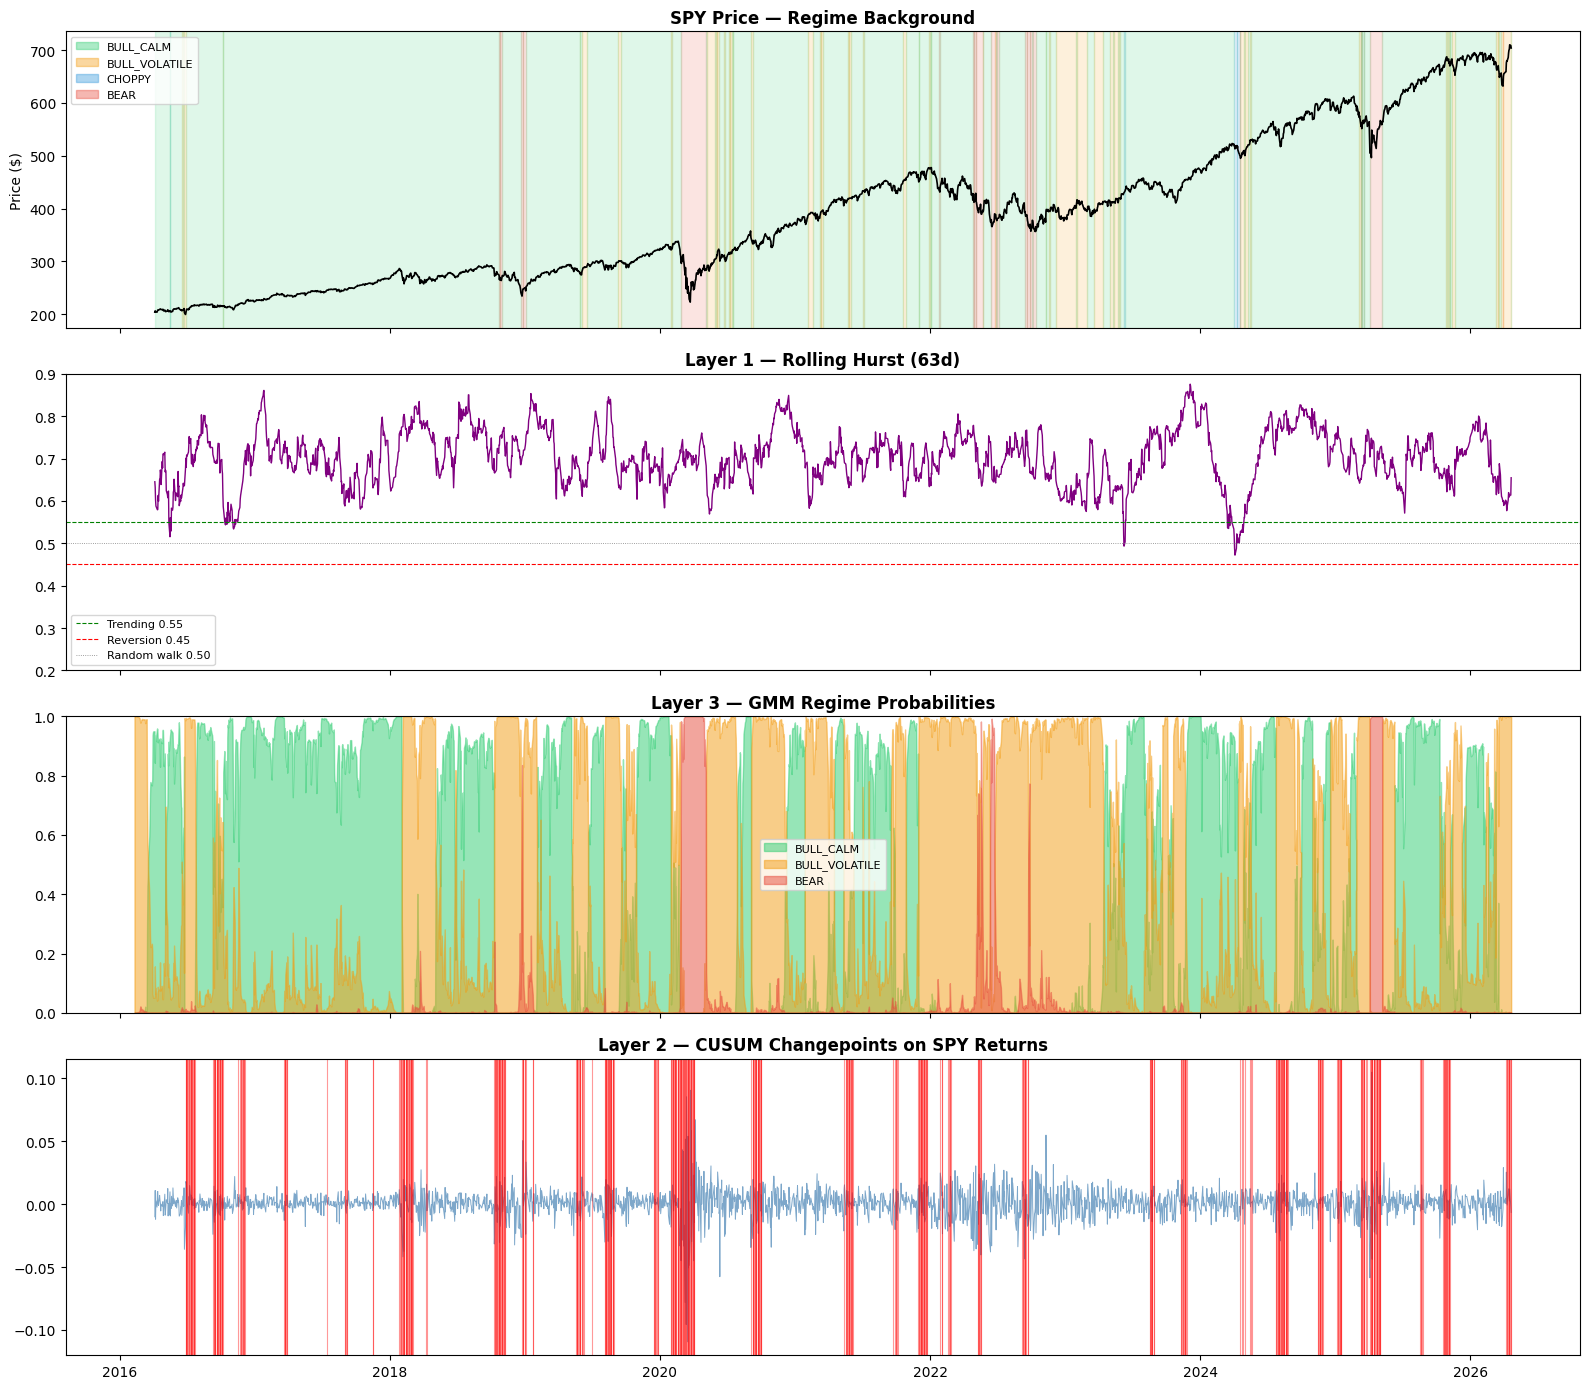

Saved → img/regime_analysis.png


In [4]:
REGIME_COLORS = {
    BULL_CALM:     "#2ecc71",
    BULL_VOLATILE: "#f39c12",
    CHOPPY:        "#3498db",
    BEAR:          "#e74c3c",
}

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
spy_close = spy_df["close"].reindex(final_regime.index)

ax = axes[0]
ax.plot(spy_close.index, spy_close.values, color="black", lw=1.2, label="SPY Close")
prev_regime = None; start_date = None
for date in final_regime.index:
    r = final_regime.loc[date]
    if r != prev_regime:
        if prev_regime is not None:
            ax.axvspan(start_date, date, alpha=0.15, color=REGIME_COLORS.get(prev_regime, "grey"))
        prev_regime = r; start_date = date
if prev_regime:
    ax.axvspan(start_date, final_regime.index[-1], alpha=0.15, color=REGIME_COLORS.get(prev_regime, "grey"))
patches = [mpatches.Patch(color=c, alpha=0.4, label=r) for r, c in REGIME_COLORS.items()]
ax.legend(handles=patches, loc="upper left", fontsize=8)
ax.set_title("SPY Price — Regime Background", fontweight="bold")
ax.set_ylabel("Price ($)")

ax = axes[1]
ax.plot(hurst_series.index, hurst_series.values, color="purple", lw=1.0)
ax.axhline(0.55, color="green", ls="--", lw=0.8, label="Trending 0.55")
ax.axhline(0.45, color="red",   ls="--", lw=0.8, label="Reversion 0.45")
ax.axhline(0.50, color="grey",  ls=":",  lw=0.6, label="Random walk 0.50")
ax.set_ylim(0.2, 0.9)
ax.set_title("Layer 1 — Rolling Hurst (63d)", fontweight="bold")
ax.legend(fontsize=8)

ax = axes[2]
for regime, color in REGIME_COLORS.items():
    if regime in regime_probs.columns:
        ax.fill_between(regime_probs.index, regime_probs[regime], alpha=0.5, label=regime, color=color)
ax.set_ylim(0, 1)
ax.set_title("Layer 3 — GMM Regime Probabilities", fontweight="bold")
ax.legend(fontsize=8)

ax = axes[3]
ax.plot(spy_returns.reindex(final_regime.index).index,
        spy_returns.reindex(final_regime.index).values,
        color="steelblue", lw=0.7, alpha=0.7)
for d in changepoint_dates:
    if d in final_regime.index:
        ax.axvline(d, color="red", alpha=0.4, lw=0.8)
ax.set_title("Layer 2 — CUSUM Changepoints on SPY Returns", fontweight="bold")

plt.tight_layout()
plt.savefig(STRATEGY_DIR / "img" / "regime_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → img/regime_analysis.png")

In [ ]:
# Per-ticker tournament summary (uses `results` + `train_ctx.calibration_summary` from 1b)
rows = []
for t in WATCHLIST:
    r = results.get(t, {})
    cal = train_ctx.calibration_summary.get(t, {})
    rows.append({
        "Ticker":        t,
        "Best Model":    r.get("best_approach", "—"),
        "OOS Sharpe":    f"{r.get('sharpe', 0):.3f}" if r else "—",
        "Passes Floor":  "✓" if r.get("passes_floor") else "✗",
        "Train Rows":    r.get("train_rows", "—"),
        "OOS Rows":      r.get("oos_rows", "—"),
        "Cal Method":    cal.get("method", "—"),
        "Cal N":         cal.get("n", "—"),
    })
summary_df = pd.DataFrame(rows).set_index("Ticker")
display(summary_df)

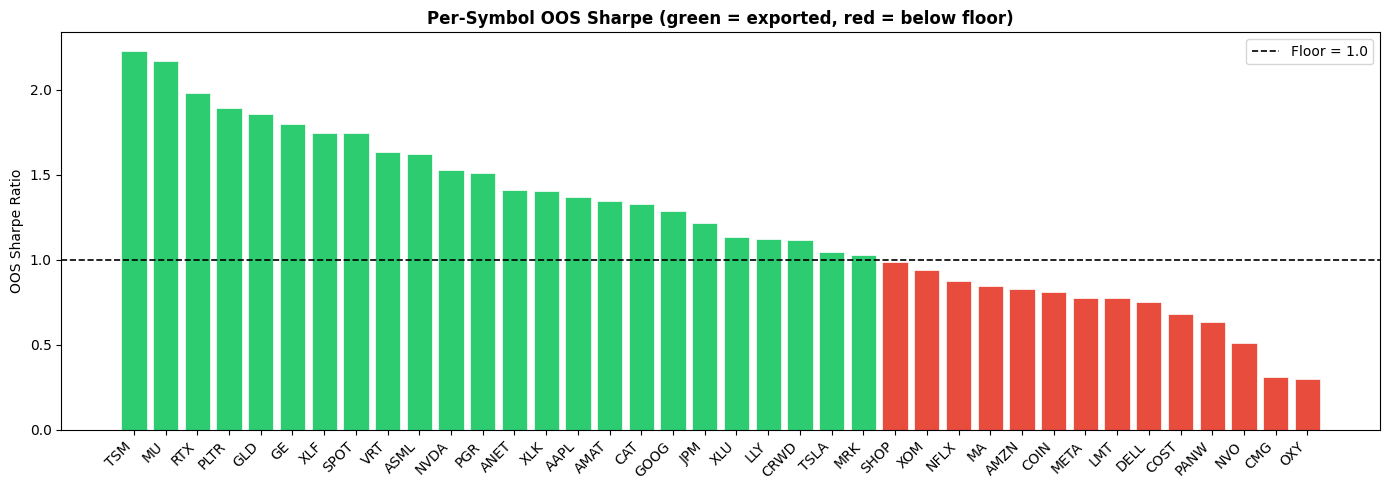

In [6]:
SHARPE_FLOOR = float(CONFIG.get("sharpe_floor", 1.0))
sharpe_vals  = {k: v.get("sharpe", 0) for k, v in results.items()}
sharpe_s     = pd.Series(sharpe_vals).sort_values(ascending=False)
colors       = ["#2ecc71" if v >= SHARPE_FLOOR else "#e74c3c" for v in sharpe_s.values]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(sharpe_s.index, sharpe_s.values, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(SHARPE_FLOOR, color="black", ls="--", lw=1.2, label=f"Floor = {SHARPE_FLOOR}")
ax.set_title("Per-Symbol OOS Sharpe (green = exported, red = below floor)", fontweight="bold")
ax.set_ylabel("OOS Sharpe Ratio")
ax.set_xticklabels(sharpe_s.index, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.savefig(STRATEGY_DIR / "img" / "model_sharpe_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# `corr_matrix` comes from 1b (train_ctx.corr_matrix)
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn_r",
            center=0, vmin=-1, vmax=1, linewidths=0.3, ax=ax, annot_kws={"size": 6})
ax.set_title("Watchlist 120-Day Return Correlation Matrix", fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(STRATEGY_DIR / "img" / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# FUNDAMENTALS COVERAGE
from kernel.fundamentals import FundamentalsStore, FACTOR_COLS
fund_store = FundamentalsStore(data_dir=ROOT / 'data' / 'fundamentals')
rows = []
for t in WATCHLIST:
    row = {'Ticker': t}
    latest = fund_store.latest(t) or {}
    for c in FACTOR_COLS:
        v = latest.get(c)
        row[c] = f'{v:.4f}' if (v is not None and v == v) else '—'
    rows.append(row)
fund_df = pd.DataFrame(rows).set_index('Ticker')
n_with_fund = sum(1 for r in rows if any(v != '—' for k, v in r.items() if k != 'Ticker'))
print(f'Fundamentals: {n_with_fund}/{len(WATCHLIST)} tickers have at least one factor')
display(fund_df)

# NGBOOST HEAD METADATA
ngb_path = STRATEGY_DIR / 'artifacts' / 'ngboost-head.json'
if not ngb_path.exists():
    print(f'NGBoost head not trained yet — artifact missing at {ngb_path}')
    ngb_head = None
else:
    from training_panel.ngboost_head import NGBoostHead
    ngb_head = NGBoostHead.load(ngb_path)
    payload = json.loads(ngb_path.read_text())
    print(f'NGBoost head loaded from {ngb_path.name}')
    print(f'  feature_cols   : {len(ngb_head.feature_cols)}')
    print(f'  trained_date   : {payload.get("trained_date")}')
    print(f'  n_rows         : {payload.get("n_rows")}')
    print(f'  train_μ_mean   : {payload.get("train_mu_mean"):+.5f}')
    print(f'  train_σ_mean   : {payload.get("train_sigma_mean"):.5f}')
    # Per-ticker μ,σ on the latest available bar (from neutralized frames + factors)
    from training_panel.pp_panel_training import SectorMomentumTask, TickerPanelNeutralizeJob, TickerPanelFactorJob, LoadFundamentalsTask
    from training_panel.context import PanelTrainingContext, TickerPanelContext
    from kernel.panel_pipeline.feature_matrix import build_inference_matrix
    _merged_cfg = dict(CONFIG); _merged_cfg['_strategy_dir'] = str(STRATEGY_DIR)
    _pctx = PanelTrainingContext(config=_merged_cfg, watchlist=list(feature_frames.keys()),
                                 ohlcv=dict(ohlcv) | {CONFIG.get('benchmark', 'SPY'): spy_df},
                                 sector_etf_ohlcv={s: ohlcv[e] for s, e in SECTOR_ETF.items() if e in ohlcv},
                                 ticker_sectors={t: CONFIG.get('sector_map', {})[t] for t in feature_frames if t in CONFIG.get('sector_map', {})})
    _pctx.feature_frames = feature_frames
    SectorMomentumTask().run(_pctx)
    LoadFundamentalsTask().run(_pctx)
    _tc_list = []
    for t in _pctx.watchlist:
        if t not in _pctx.feature_frames: continue
        tc = TickerPanelContext(ticker=t, ohlcv=_pctx.ohlcv, sector_momentum=_pctx.sector_momentum,
                                 ticker_sectors=_pctx.ticker_sectors, config=_pctx.config,
                                 fundamentals=_pctx.fundamentals)
        tc.feature_frame = _pctx.feature_frames[t]
        TickerPanelNeutralizeJob().run(tc)
        TickerPanelFactorJob().run(tc)
        _tc_list.append(tc)
    _ff   = {tc.ticker: tc.neutralized_frame for tc in _tc_list if tc.neutralized_frame is not None}
    _fac  = {tc.ticker: tc.raw_factor_frame  for tc in _tc_list if tc.raw_factor_frame  is not None}
    # Score the latest bar
    last_day = max(f.index.max() for f in _ff.values())
    X = build_inference_matrix(_ff, _fac, last_day, feature_cols=ngb_head.feature_cols,
                                nan_prone_cols=CONFIG.get('panel_ltr', {}).get('nan_prone_cols', []))
    if not X.empty:
        dist = ngb_head.predict_distribution(X)
        dist['mu_minus_sigma'] = dist['mu'] - dist['sigma']
        dist = dist.sort_values('mu_minus_sigma', ascending=False)
        print(f'\nNGBoost μ,σ on {last_day.date()} (sorted by μ-σ):')
        display(dist.head(20))

## 3  Simulate

In [ ]:
# Baseline sim (panel scoring OFF) — pure per-ticker tournament scores.
# LoadUniverseJob loads all on-disk models; InferencePipeline drives per-bar
# decisions (regime -> drawdown -> sells -> candidates -> ranking -> selection).
from sim.runner import run_backtest

_corr_fallback = {
    t: {o: round(float(corr_matrix.loc[t, o]), 4) for o in corr_matrix.columns}
    for t in corr_matrix.index
}

sim_cfg_baseline = dict(CONFIG)
sim_cfg_baseline["initial_cash"]   = 100_000
sim_cfg_baseline["_strategy_dir"]  = str(STRATEGY_DIR)
# Switch the panel flag off for this run (baseline) without mutating CONFIG
sim_cfg_baseline["ranking"] = dict(CONFIG.get("ranking", {}))
sim_cfg_baseline["ranking"]["panel_scoring"] = dict(
    sim_cfg_baseline["ranking"].get("panel_scoring", {})
)
sim_cfg_baseline["ranking"]["panel_scoring"]["enabled"] = False

baseline_sim = run_backtest(
    config         = sim_cfg_baseline,
    strategy_dir   = STRATEGY_DIR,
    ohlcv          = ohlcv,
    spy_df         = spy_df,
    sector_etf_map = SECTOR_ETF,
    fallback_corr  = _corr_fallback,
)
print()
baseline_sim.print_summary()

In [ ]:
# Panel-LTR sim — builds neutralized + raw-factor frames over full OHLCV
# history (walk-forward safe), then reuses the same InferencePipeline. The
# only difference vs baseline is ranking.panel_scoring.enabled = True, which
# activates PanelScoringJob inside the pipeline.
from training_panel.context         import PanelTrainingContext, TickerPanelContext
from training_panel.pp_panel_training import (
    SectorMomentumTask, TickerPanelNeutralizeJob, TickerPanelFactorJob,
    LoadFundamentalsTask,
)

panel_sim = None
if not panel_artifact_path.exists():
    print(f"Panel artifact not found at {panel_artifact_path} — skipping panel sim.")
else:
    benchmark        = CONFIG.get("benchmark", "SPY")
    sector_map       = CONFIG.get("sector_map", {})
    sector_etf_ohlcv = {s: ohlcv[etf] for s, etf in SECTOR_ETF.items() if etf in ohlcv}
    ticker_sectors   = {t: sector_map[t] for t in feature_frames if t in sector_map}
    merged_cfg = dict(CONFIG)
    merged_cfg["_strategy_dir"] = str(STRATEGY_DIR)

    pctx = PanelTrainingContext(
        config=merged_cfg, watchlist=list(feature_frames.keys()),
        ohlcv=dict(ohlcv) | {benchmark: spy_df},
        sector_etf_ohlcv=sector_etf_ohlcv, ticker_sectors=ticker_sectors,
    )
    pctx.feature_frames = feature_frames
    SectorMomentumTask().run(pctx)
    LoadFundamentalsTask().run(pctx)

    ticker_ctxs = []
    for t in pctx.watchlist:
        if t not in pctx.feature_frames:
            continue
        tc = TickerPanelContext(ticker=t, ohlcv=pctx.ohlcv,
                                 sector_momentum=pctx.sector_momentum,
                                 ticker_sectors=pctx.ticker_sectors, config=pctx.config,
                                 fundamentals=pctx.fundamentals)
        tc.feature_frame = pctx.feature_frames[t]
        TickerPanelNeutralizeJob().run(tc)
        TickerPanelFactorJob().run(tc)
        ticker_ctxs.append(tc)

    pctx.neutralized_frames = {tc.ticker: tc.neutralized_frame for tc in ticker_ctxs if tc.neutralized_frame is not None}
    pctx.raw_factor_frames  = {tc.ticker: tc.raw_factor_frame  for tc in ticker_ctxs if tc.raw_factor_frame is not None}

    sim_cfg_panel = dict(CONFIG)
    sim_cfg_panel["initial_cash"]  = 100_000
    sim_cfg_panel["_strategy_dir"] = str(STRATEGY_DIR)

    panel_sim = run_backtest(
        config               = sim_cfg_panel,
        strategy_dir         = STRATEGY_DIR,
        ohlcv                = ohlcv,
        spy_df               = spy_df,
        sector_etf_map       = SECTOR_ETF,
        fallback_corr        = _corr_fallback,
        panel_feature_frames = pctx.neutralized_frames,
        panel_factor_frames  = pctx.raw_factor_frames,
    )
    print()
    panel_sim.print_summary()

## 4  Analyze

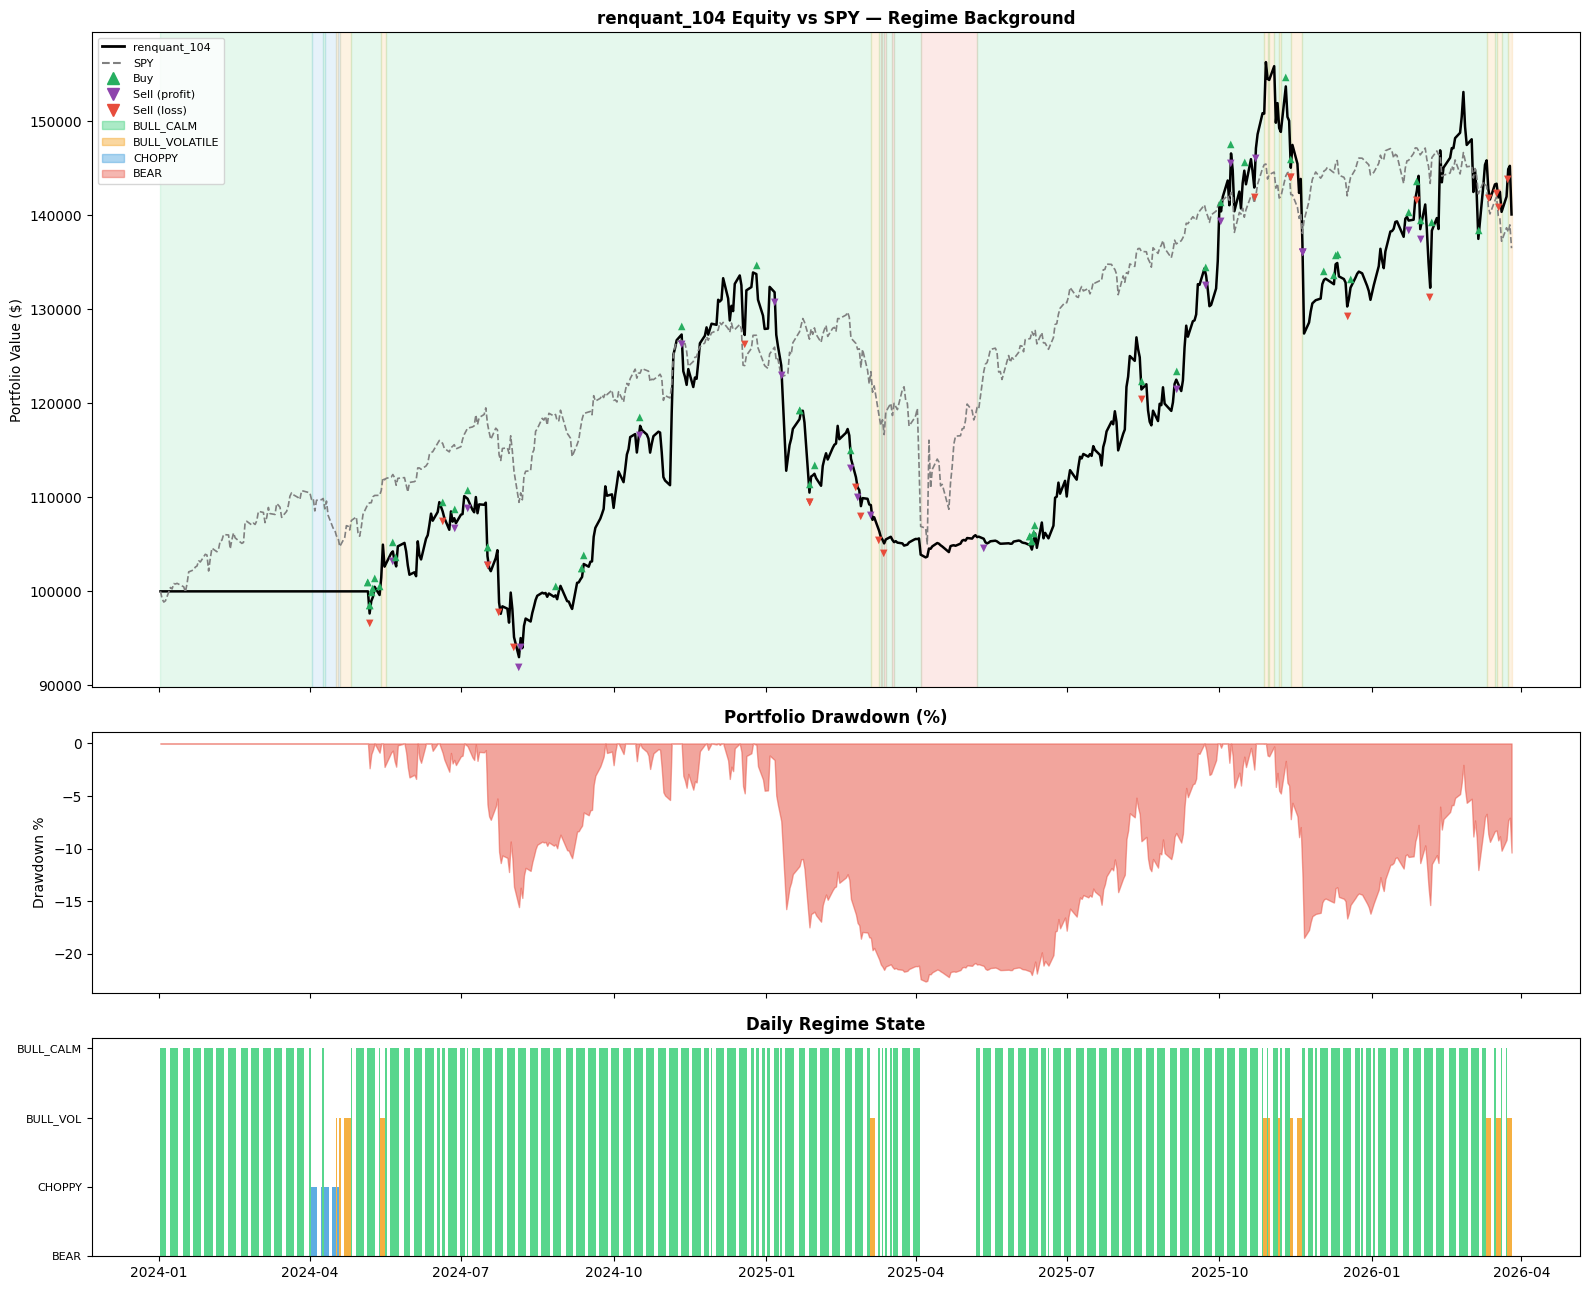

In [12]:
ACTIVE_SIM = baseline_sim           # toggle to panel_sim to plot the panel run
equity_df  = ACTIVE_SIM.equity_df
trade_log  = ACTIVE_SIM.trade_log

BACKTEST_START = CONFIG["backtest_start"]
BACKTEST_END   = CONFIG["backtest_end"]
INITIAL_CASH   = sim_cfg["initial_cash"]

spy_bt   = spy_df["close"].loc[BACKTEST_START:BACKTEST_END]
spy_norm = spy_bt / spy_bt.iloc[0] * INITIAL_CASH

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1.2, 1]})

ax = axes[0]
port_norm = equity_df["portfolio"]
prev_r = None; start_d = None
for d in equity_df.index:
    r = equity_df.loc[d, "regime"]
    if r != prev_r:
        if prev_r:
            ax.axvspan(start_d, d, alpha=0.12, color=REGIME_COLORS.get(prev_r, "grey"))
        prev_r = r; start_d = d
if prev_r:
    ax.axvspan(start_d, equity_df.index[-1], alpha=0.12, color=REGIME_COLORS.get(prev_r, "grey"))

ax.plot(port_norm.index, port_norm.values, color="black", lw=1.8, label="renquant_104")
ax.plot(spy_norm.index,  spy_norm.values,  color="grey",  lw=1.2, ls="--", label="SPY")

for t in trade_log:
    if t["date"] not in port_norm.index:
        continue
    if t["action"] == "buy":
        ax.annotate("▲", xy=(t["date"], port_norm.loc[t["date"]]),
                    fontsize=7, color="#27ae60", ha="center", va="bottom",
                    xytext=(0, 3), textcoords="offset points")
    else:
        c = "#e74c3c" if t.get("pnl_pct", 0) < 0 else "#8e44ad"
        ax.annotate("▼", xy=(t["date"], port_norm.loc[t["date"]]),
                    fontsize=7, color=c, ha="center", va="top",
                    xytext=(0, -3), textcoords="offset points")

patches = [mpatches.Patch(color=c, alpha=0.4, label=r) for r, c in REGIME_COLORS.items()]
ax.legend(handles=[
    plt.Line2D([0],[0], color="black", lw=2, label="renquant_104"),
    plt.Line2D([0],[0], color="grey",  lw=1.5, ls="--", label="SPY"),
    plt.Line2D([0],[0], marker="^", color="#27ae60", lw=0, markersize=8, label="Buy"),
    plt.Line2D([0],[0], marker="v", color="#8e44ad", lw=0, markersize=8, label="Sell (profit)"),
    plt.Line2D([0],[0], marker="v", color="#e74c3c", lw=0, markersize=8, label="Sell (loss)"),
] + patches, fontsize=8)
ax.set_title("renquant_104 Equity vs SPY — Regime Background", fontweight="bold")
ax.set_ylabel("Portfolio Value ($)")

ax = axes[1]
roll_max = port_norm.cummax()
drawdown = (port_norm - roll_max) / roll_max * 100
ax.fill_between(drawdown.index, drawdown.values, 0, color="#e74c3c", alpha=0.5)
ax.set_title("Portfolio Drawdown (%)", fontweight="bold")
ax.set_ylabel("Drawdown %")

ax = axes[2]
regime_numeric = {BULL_CALM: 3, BULL_VOLATILE: 2, CHOPPY: 1, BEAR: 0}
regime_vals    = equity_df["regime"].map(regime_numeric).fillna(-1)
colors_seq     = equity_df["regime"].map(REGIME_COLORS).fillna("grey")
ax.bar(regime_vals.index, regime_vals.values, color=colors_seq.values, width=1, alpha=0.8)
ax.set_yticks([0,1,2,3]); ax.set_yticklabels(["BEAR","CHOPPY","BULL_VOL","BULL_CALM"], fontsize=8)
ax.set_title("Daily Regime State", fontweight="bold")

plt.tight_layout()
plt.savefig(STRATEGY_DIR / "img" / "portfolio_simulation.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
def calc_stats(series):
    s = series.dropna()
    dr = s.pct_change().dropna()
    n_years = len(dr) / 252
    total_return = s.iloc[-1] / s.iloc[0] - 1
    cagr   = (1 + total_return) ** (1 / n_years) - 1 if n_years > 0 else 0
    sharpe = float(dr.mean() / dr.std() * np.sqrt(252)) if dr.std() > 0 else 0
    roll_max = s.cummax()
    max_dd   = float(((s - roll_max) / roll_max).min())
    vol      = float(dr.std() * np.sqrt(252))
    return {"total_return": total_return, "apy": cagr, "sharpe": sharpe,
            "max_drawdown": max_dd, "volatility": vol}

b_stats = calc_stats(baseline_sim.equity_df["portfolio"])
s_stats = calc_stats(spy_norm)
p_stats = calc_stats(panel_sim.equity_df["portfolio"]) if panel_sim is not None else None

cols = ["Baseline", "SPY"] + (["Panel-LTR"] if p_stats else [])
print("=" * (27 + 12 * len(cols)))
header = f"{'Metric':<25}" + "".join(f"{c:>12}" for c in cols)
print(header)
print("=" * (27 + 12 * len(cols)))
for k in ["total_return", "apy", "sharpe", "max_drawdown", "volatility"]:
    row = f"{k:<25}"
    for d in [b_stats, s_stats] + ([p_stats] if p_stats else []):
        v = d.get(k, 0)
        row += f"{v:>11.1%} " if k in ("total_return", "apy", "max_drawdown", "volatility") else f"{v:>12.3f}"
    print(row)
print("=" * (27 + 12 * len(cols)))

print("\nRegime days (baseline sim):")
for r, c in REGIME_COLORS.items():
    n = (baseline_sim.equity_df["regime"] == r).sum()
    print(f"  {r:<16} {n:>4}d  {n/len(baseline_sim.equity_df):.1%}")

Metric                       Baseline         SPY   Panel-LTR
total_return                   40.1%       36.5%       30.0% 
apy                            16.4%       15.1%       12.5% 
sharpe                          0.775       0.952       0.678
max_drawdown                  -22.6%      -19.0%      -18.1% 
volatility                     23.1%       16.1%       20.5% 

Regime days (baseline sim):
  BULL_CALM         493d  88.0%
  BULL_VOLATILE      30d  5.4%
  CHOPPY             11d  2.0%
  BEAR               26d  4.6%


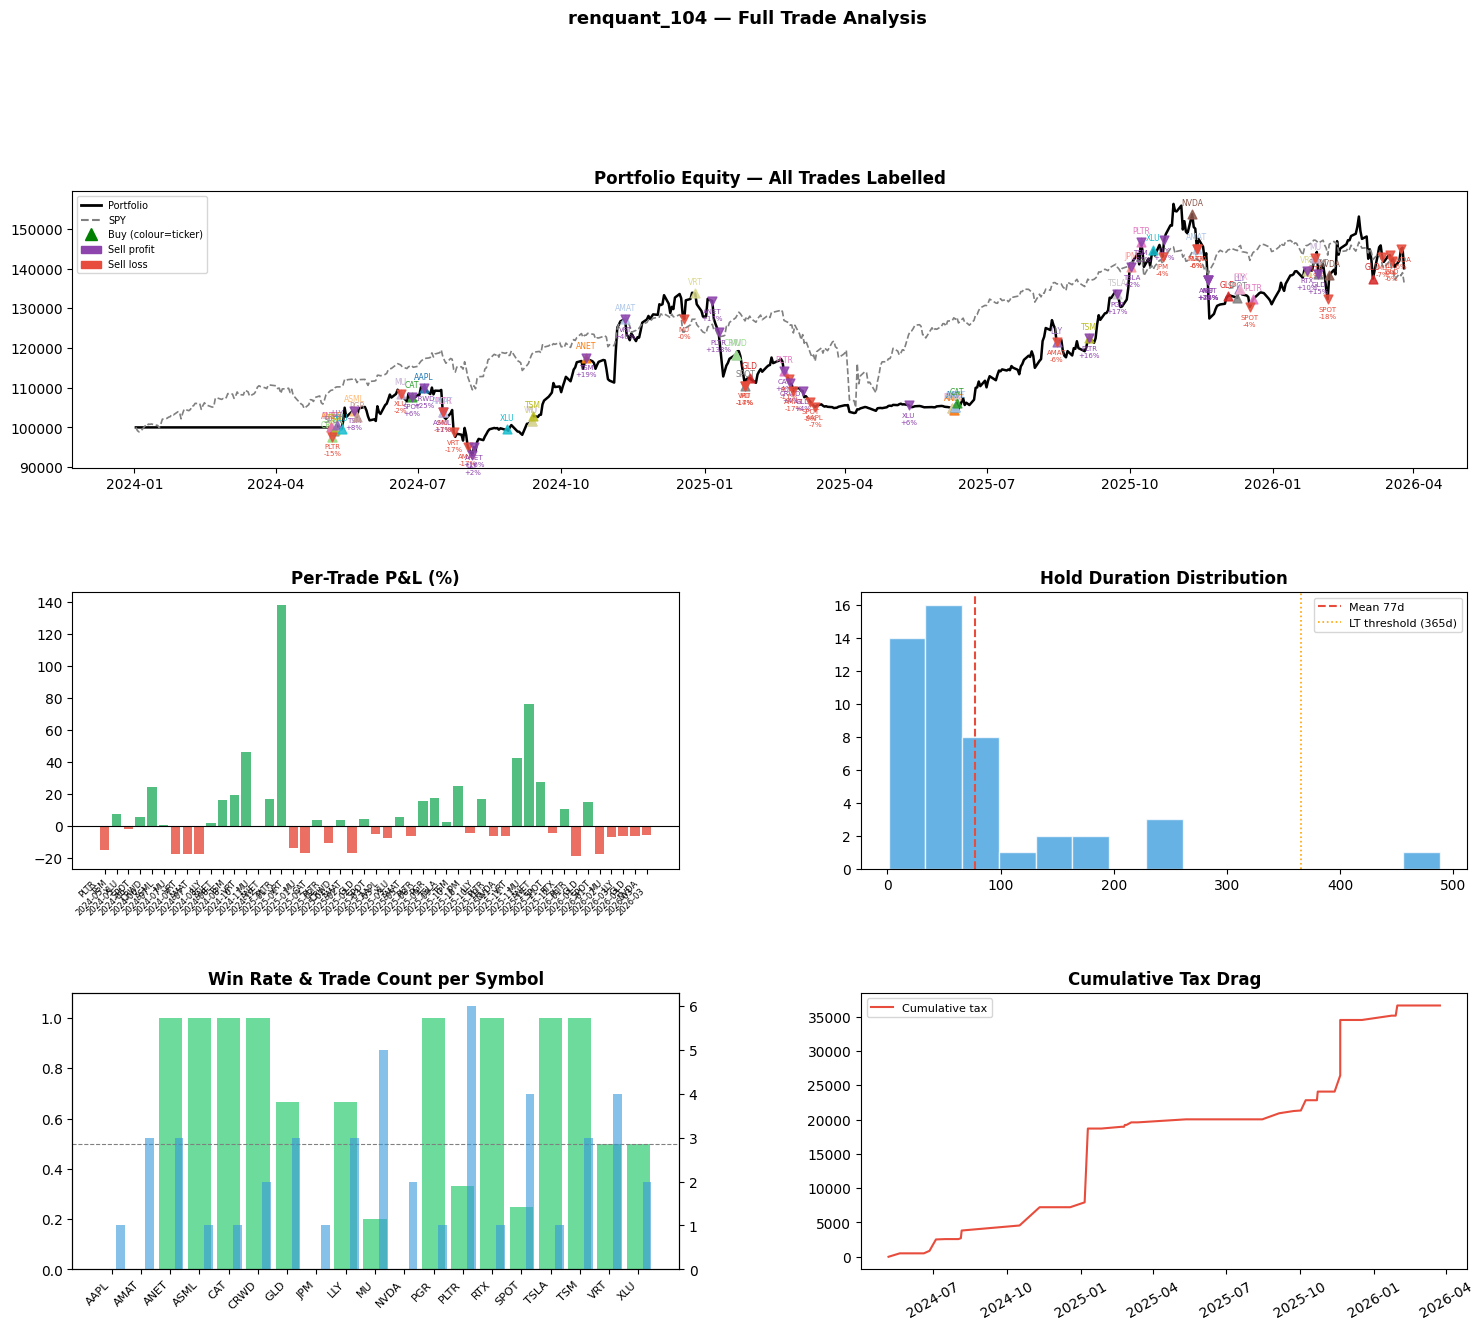

Saved → /Users/renhao/git/github/RenQuant/backtesting/renquant_104/img/trade_analysis.png


In [14]:
import matplotlib.gridspec as gridspec

sells = baseline_sim.sells
buys  = baseline_sim.buys

if not sells and not buys:
    print("No trades to chart.")
else:
    tickers_traded = sorted(set([t["ticker"] for t in buys + sells]))
    colors_t = plt.cm.tab20.colors

    fig = plt.figure(figsize=(18, 14))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

    ax0 = fig.add_subplot(gs[0, :])
    ax0.plot(equity_df.index, equity_df["portfolio"], color="black", lw=1.8, label="Portfolio")
    ax0.plot(spy_norm.index, spy_norm.values, color="grey", lw=1.2, ls="--", label="SPY")
    ticker_colors = {t: colors_t[i % 20] for i, t in enumerate(tickers_traded)}
    for trade in buys:
        d = trade["date"]
        if d in equity_df.index:
            c = ticker_colors.get(trade["ticker"], "green")
            ax0.scatter(d, equity_df.loc[d, "portfolio"], marker="^", color=c, s=40, zorder=5, alpha=0.85)
            ax0.annotate(trade["ticker"], xy=(d, equity_df.loc[d, "portfolio"]),
                         fontsize=5.5, color=c, ha="center", va="bottom",
                         xytext=(0, 5), textcoords="offset points")
    for trade in sells:
        d = trade["date"]
        if d in equity_df.index:
            c = "#e74c3c" if trade["pnl_pct"] < 0 else "#8e44ad"
            ax0.scatter(d, equity_df.loc[d, "portfolio"], marker="v", color=c, s=40, zorder=5, alpha=0.85)
            ax0.annotate(f"{trade['ticker']}\n{trade['pnl_pct']:+.0%}",
                         xy=(d, equity_df.loc[d, "portfolio"]),
                         fontsize=5, color=c, ha="center", va="top",
                         xytext=(0, -5), textcoords="offset points")
    ax0.legend(handles=[
        plt.Line2D([0],[0], color="black", lw=2, label="Portfolio"),
        plt.Line2D([0],[0], color="grey",  lw=1.5, ls="--", label="SPY"),
        plt.Line2D([0],[0], marker="^", color="green", lw=0, markersize=8, label="Buy (colour=ticker)"),
        mpatches.Patch(color="#8e44ad", label="Sell profit"),
        mpatches.Patch(color="#e74c3c", label="Sell loss"),
    ], fontsize=7, loc="upper left")
    ax0.set_title("Portfolio Equity — All Trades Labelled", fontweight="bold")

    ax1 = fig.add_subplot(gs[1, 0])
    if sells:
        ss = sorted(sells, key=lambda x: x["date"])
        labels = [f"{t['ticker']}\n{str(t['date'])[:7]}" for t in ss]
        pnls   = [t["pnl_pct"] * 100 for t in ss]
        bc     = ["#e74c3c" if p < 0 else "#27ae60" for p in pnls]
        ax1.bar(range(len(pnls)), pnls, color=bc, alpha=0.8)
        ax1.set_xticks(range(len(pnls)))
        ax1.set_xticklabels(labels, fontsize=6, rotation=45, ha="right")
        ax1.axhline(0, color="black", lw=0.8)
        ax1.set_title("Per-Trade P&L (%)", fontweight="bold")

    ax2 = fig.add_subplot(gs[1, 1])
    if sells:
        hd = [t["hold_days"] for t in sells]
        ax2.hist(hd, bins=15, color="#3498db", alpha=0.75, edgecolor="white")
        ax2.axvline(np.mean(hd), color="#e74c3c", lw=1.5, ls="--", label=f"Mean {np.mean(hd):.0f}d")
        ax2.axvline(365, color="orange", lw=1.2, ls=":", label="LT threshold (365d)")
        ax2.legend(fontsize=8); ax2.set_title("Hold Duration Distribution", fontweight="bold")

    ax3 = fig.add_subplot(gs[2, 0])
    if sells:
        sym_data: dict = {}
        for t in sells:
            sym_data.setdefault(t["ticker"], {"wins":0,"total":0})
            sym_data[t["ticker"]]["total"] += 1
            if t["pnl_pct"] > 0:
                sym_data[t["ticker"]]["wins"] += 1
        syms   = sorted(sym_data)
        wr     = [sym_data[s]["wins"] / sym_data[s]["total"] for s in syms]
        counts = [sym_data[s]["total"] for s in syms]
        x = range(len(syms))
        ax3.bar(x, wr, color="#2ecc71", alpha=0.7, label="Win rate")
        ax3_r = ax3.twinx()
        ax3_r.bar([i + 0.3 for i in x], counts, width=0.3, color="#3498db", alpha=0.6, label="# trades")
        ax3.set_xticks(x); ax3.set_xticklabels(syms, rotation=45, ha="right", fontsize=8)
        ax3.set_ylim(0, 1.1); ax3.axhline(0.5, color="grey", lw=0.8, ls="--")
        ax3.set_title("Win Rate & Trade Count per Symbol", fontweight="bold")

    ax4 = fig.add_subplot(gs[2, 1])
    if sells:
        ss = sorted(sells, key=lambda x: x["date"])
        cum_tax = np.cumsum([t["tax"] for t in ss])
        ax4.plot([t["date"] for t in ss], cum_tax, color="#e74c3c", lw=1.5, label="Cumulative tax")
        ax4.set_title("Cumulative Tax Drag", fontweight="bold"); ax4.legend(fontsize=8)
        ax4.tick_params(axis="x", rotation=30)

    plt.suptitle("renquant_104 — Full Trade Analysis", fontsize=13, fontweight="bold", y=1.01)
    plt.savefig(STRATEGY_DIR / "img" / "trade_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {STRATEGY_DIR / 'img' / 'trade_analysis.png'}")

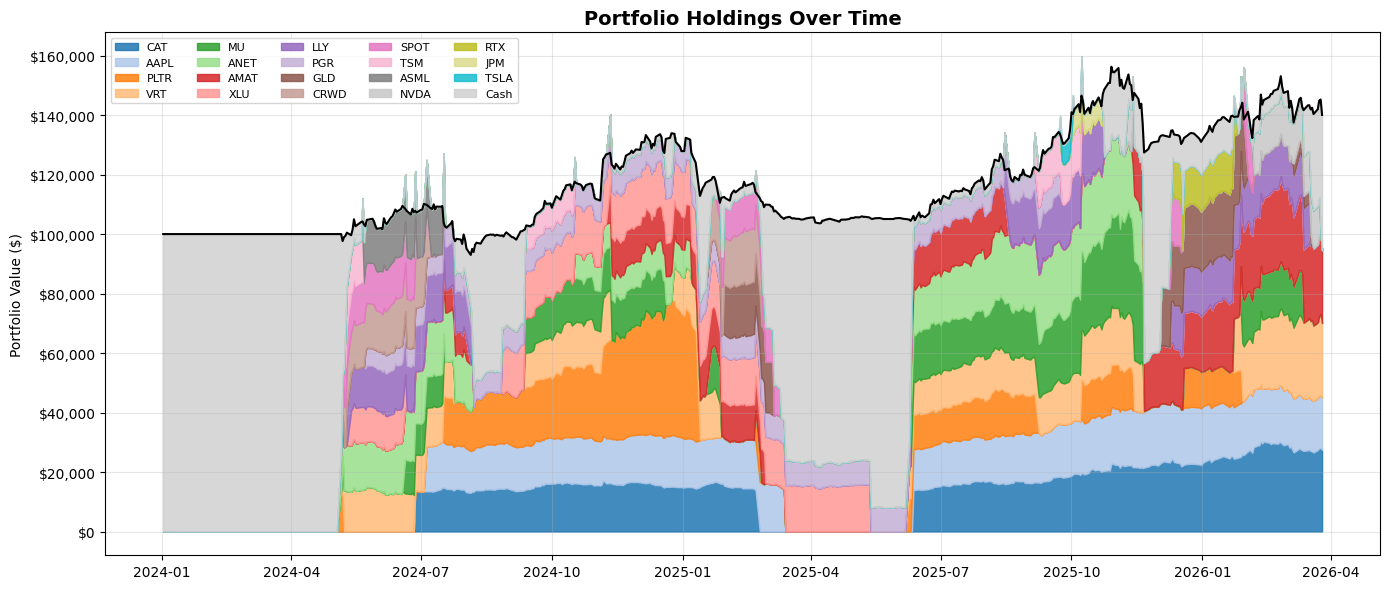

Saved → img/holdings_over_time.png


In [15]:
if trade_log:
    tdf_h = pd.DataFrame(trade_log)
    tdf_h["date"] = pd.to_datetime(tdf_h["date"])
    bt_idx = equity_df.index
    open_pos: dict = {}
    ticker_daily: dict = {}

    for _, row in tdf_h.sort_values("date").iterrows():
        t = row["ticker"]
        if row["action"] == "buy":
            open_pos.setdefault(t, []).append({"buy_date": row["date"], "shares": float(row["shares"])})
        elif row["action"] == "sell" and open_pos.get(t):
            pos = open_pos[t].pop(0)
            if t in ohlcv:
                prices = ohlcv[t]["close"].loc[pos["buy_date"]:row["date"]]
                prices = prices[prices.index.isin(bt_idx)]
                ticker_daily.setdefault(t, pd.Series(0.0, index=bt_idx))
                ticker_daily[t] = ticker_daily[t].add(prices * pos["shares"], fill_value=0)

    for t, positions_list in open_pos.items():
        for pos in positions_list:
            if t in ohlcv:
                prices = ohlcv[t]["close"].loc[pos["buy_date"]:]
                prices = prices[prices.index.isin(bt_idx)]
                ticker_daily.setdefault(t, pd.Series(0.0, index=bt_idx))
                ticker_daily[t] = ticker_daily[t].add(prices * pos["shares"], fill_value=0)

    if ticker_daily:
        hdf = pd.DataFrame(ticker_daily, index=bt_idx).fillna(0)
        hdf["Cash"] = (equity_df["portfolio"] - hdf.sum(axis=1)).clip(lower=0)
        stock_cols = sorted([c for c in hdf.columns if c != "Cash"], key=lambda c: hdf[c].sum(), reverse=True)

        fig, ax = plt.subplots(figsize=(14, 6))
        colors = plt.cm.tab20.colors
        bottom = pd.Series(0.0, index=bt_idx)
        for i, col in enumerate(stock_cols + ["Cash"]):
            color = "#d0d0d0" if col == "Cash" else colors[i % len(colors)]
            ax.fill_between(hdf.index, bottom, bottom + hdf[col], label=col, alpha=0.85, color=color)
            bottom = bottom + hdf[col]
        ax.plot(equity_df["portfolio"], color="black", lw=1.5, zorder=5)
        ax.set_title("Portfolio Holdings Over Time", fontsize=14, fontweight="bold")
        ax.set_ylabel("Portfolio Value ($)")
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
        ax.legend(loc="upper left", fontsize=8, ncol=5)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(STRATEGY_DIR / "img" / "holdings_over_time.png", dpi=150)
        plt.show()
        print("Saved → img/holdings_over_time.png")

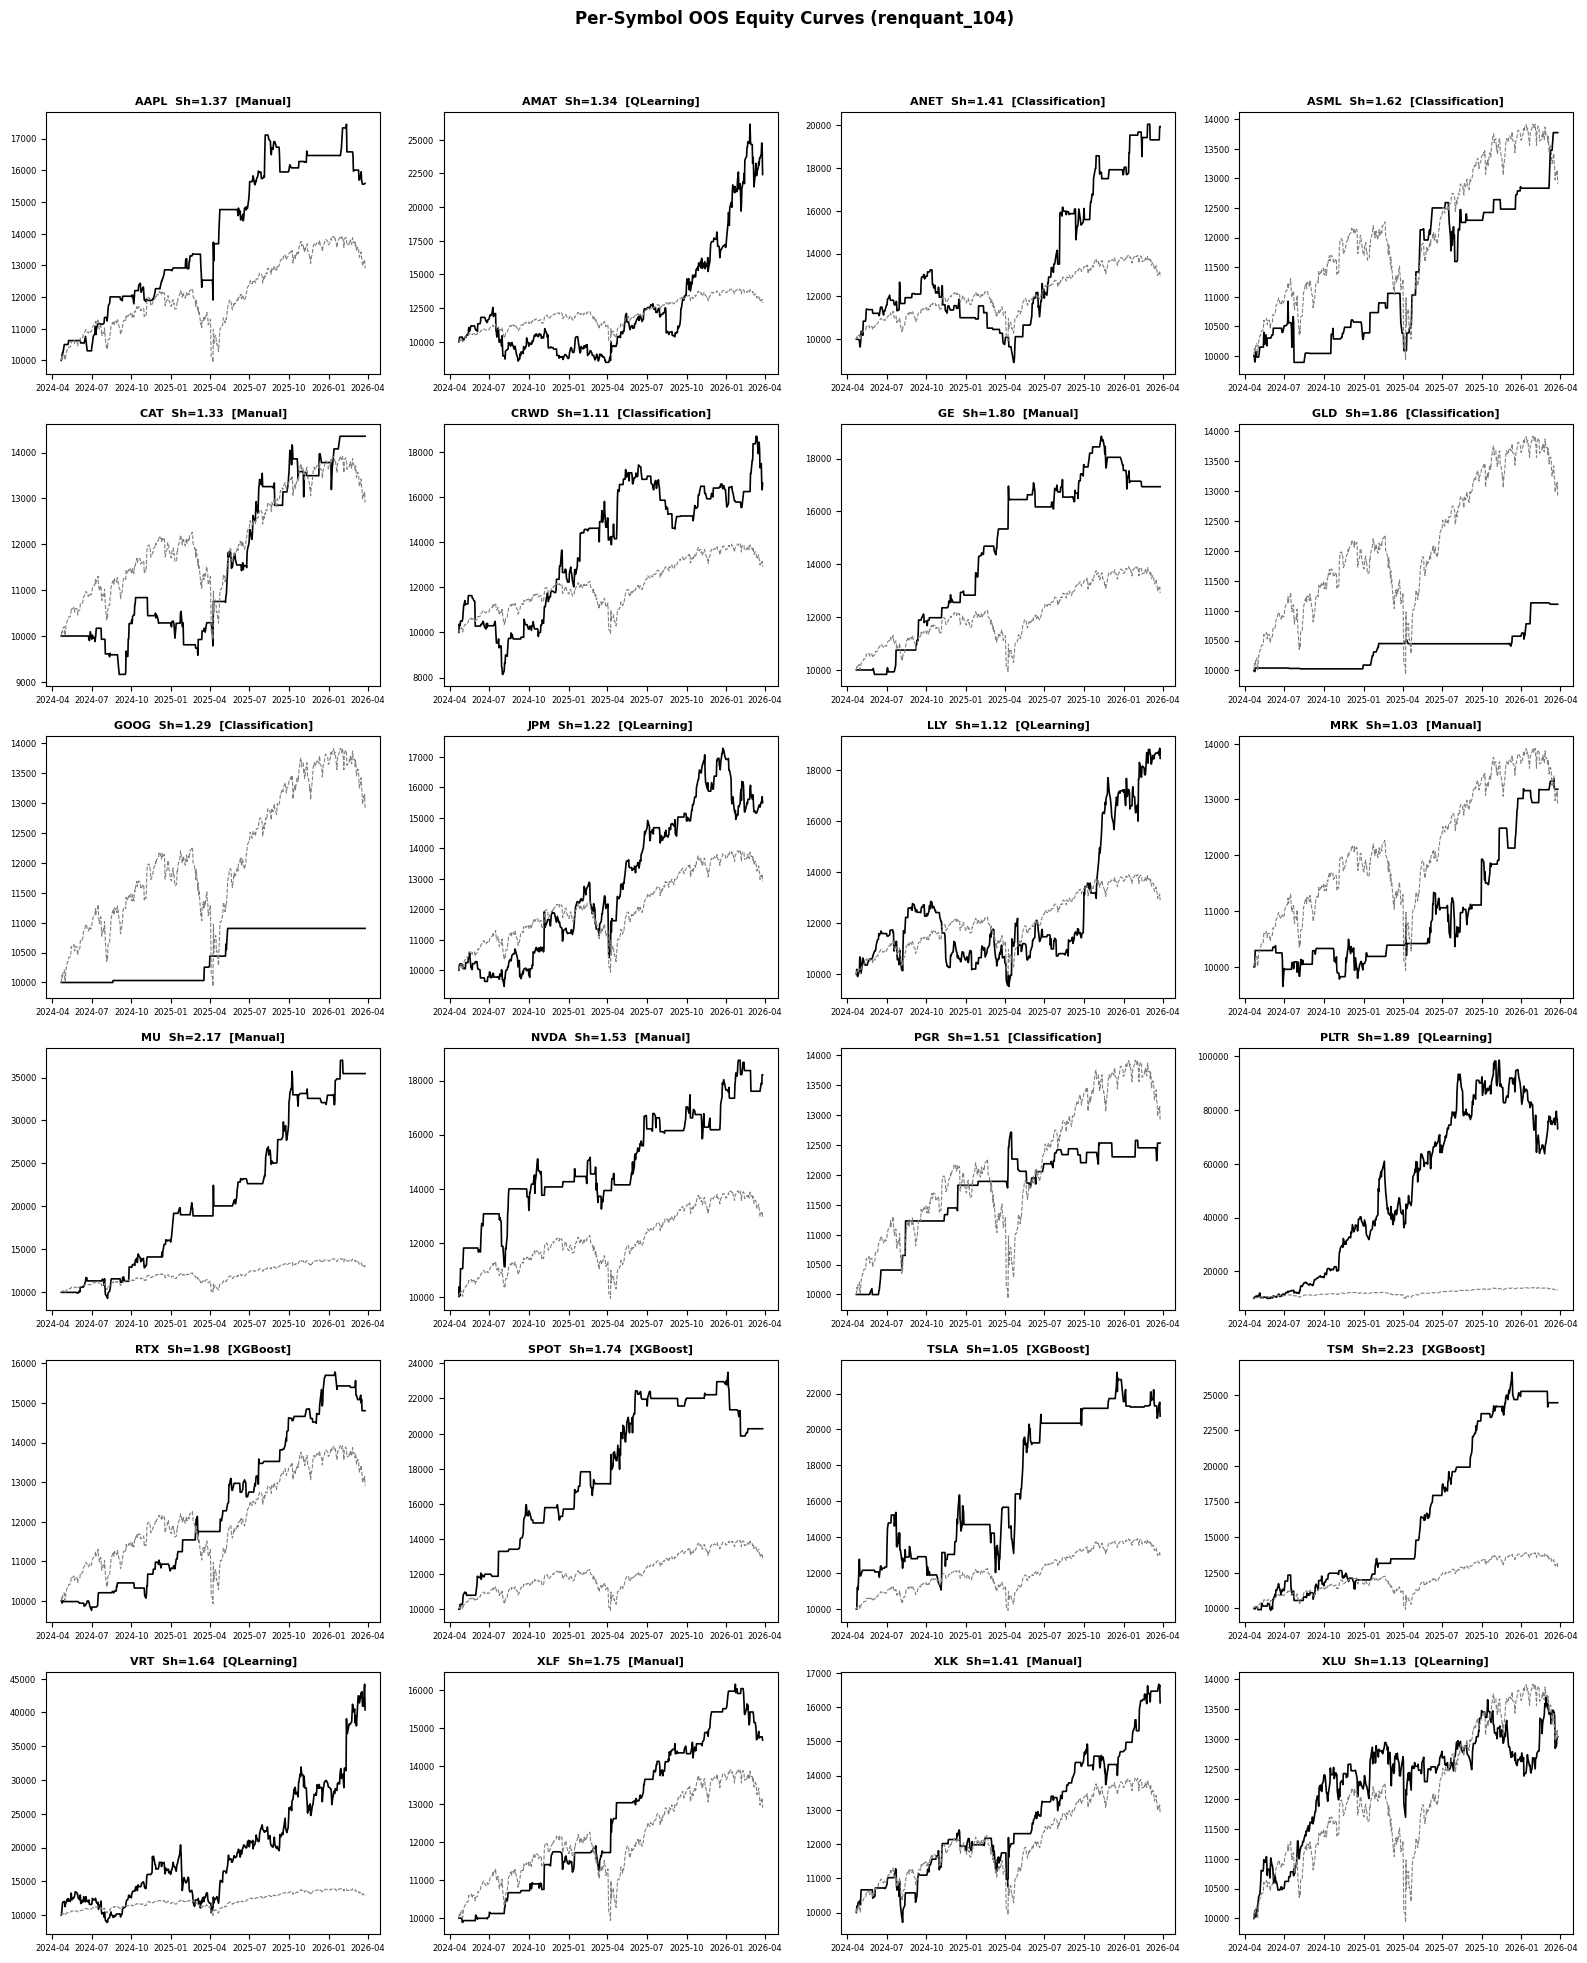

In [16]:
pass_tickers = sorted([t for t, r in results.items() if r.get("passes_floor")])

if not pass_tickers:
    print("No models passed the Sharpe floor.")
else:
    ncols = 4
    nrows = max(1, (len(pass_tickers) + ncols - 1) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.2))
    axes = np.array(axes).flatten()
    spy_oos_close = spy_df["close"].loc[BACKTEST_START:BACKTEST_END]

    for i, ticker in enumerate(pass_tickers):
        ax     = axes[i]
        r      = results[ticker]
        sigs   = r.get("oos_signals")
        prices = r.get("oos_prices")
        if sigs is None or prices is None or prices.empty:
            ax.set_title(f"{ticker} — no OOS data", fontsize=8); continue
        prices = prices.loc[BACKTEST_START:BACKTEST_END]
        if prices.empty:
            ax.set_title(f"{ticker} — empty", fontsize=8); continue
        sigs_bt = sigs.reindex(prices.index).fillna(0)
        try:
            pos = sigs_bt.clip(0, 1).shift(1).fillna(0)
            strat_ret = prices.pct_change().fillna(0) * pos
            pv = 10_000 * (1 + strat_ret).cumprod()
            spy_sub = spy_oos_close.reindex(prices.index)
            spy_sub = spy_sub / spy_sub.iloc[0] * 10_000
            ax.plot(pv.index, pv.values, color="black", lw=1.2, label="Model")
            ax.plot(spy_sub.index, spy_sub.values, color="grey", lw=0.8, ls="--", label="SPY")
            ax.set_title(f"{ticker}  Sh={r['sharpe']:.2f}  [{r['best_approach']}]", fontsize=8, fontweight="bold")
            ax.tick_params(labelsize=6)
        except Exception as e:
            ax.set_title(f"{ticker} — error", fontsize=7)

    for j in range(len(pass_tickers), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Per-Symbol OOS Equity Curves (renquant_104)", fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(STRATEGY_DIR / "img" / "per_symbol_oos.png", dpi=150, bbox_inches="tight")
    plt.show()

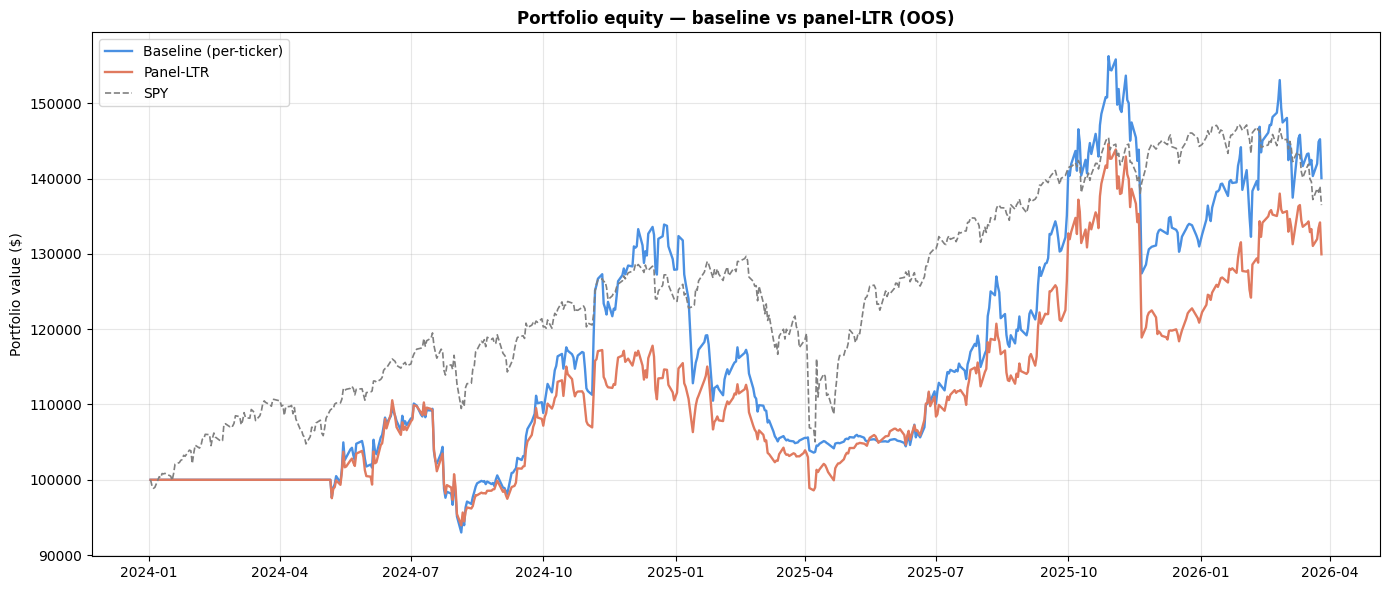

Saved → img/compare_panel_vs_baseline.png


In [17]:
if panel_sim is None:
    print("Panel sim was not run — skipping comparison chart.")
else:
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(baseline_sim.equity_df.index, baseline_sim.equity_df["portfolio"],
            color="#4a90e2", lw=1.7, label="Baseline (per-ticker)")
    ax.plot(panel_sim.equity_df.index, panel_sim.equity_df["portfolio"],
            color="#e07a5f", lw=1.7, label="Panel-LTR")
    ax.plot(spy_norm.index, spy_norm.values, color="grey", lw=1.2, ls="--", label="SPY")
    ax.set_title("Portfolio equity — baseline vs panel-LTR (OOS)", fontweight="bold")
    ax.set_ylabel("Portfolio value ($)")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig(STRATEGY_DIR / "img" / "compare_panel_vs_baseline.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → img/compare_panel_vs_baseline.png")

## 5  Utilities

In [18]:
import subprocess
result = subprocess.run(
    [sys.executable, str(ROOT / "scripts" / "fetch_earnings_calendar.py"),
     "--strategy", STRATEGY, "--lookahead", "90"],
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)

Fetching earnings calendar for 38 symbols → /Users/renhao/git/github/RenQuant/backtesting/renquant_104/artifacts/earnings-calendar.json
  AAPL... 1 dates
  AMZN... 1 dates
  ASML... 2 dates
  GOOG... 1 dates
  META... 1 dates
  MU... 1 dates
  NFLX... 2 dates
  NVDA... 1 dates
  PLTR... 1 dates
  TSLA... 1 dates
  TSM... 2 dates
  DELL... 1 dates
  ANET... 1 dates
  VRT... 1 dates
  PANW... 1 dates
  SHOP... 1 dates
  CRWD... 1 dates
  AMAT... 1 dates
  SPOT... 1 dates
  JPM... 2 dates
  MA... 1 dates
  XLF... 0 dates
  COIN... 1 dates
  PGR... 2 dates
  LLY... 1 dates
  MRK... 1 dates
  NVO... 1 dates
  CAT... 1 dates
  RTX... 1 dates
  GE... 1 dates
  LMT... 1 dates
  COST... 1 dates
  CMG... 1 dates
  XOM... 1 dates
  OXY... 1 dates
  GLD... 0 dates
  XLU... 0 dates
  XLK... 0 dates

Saved → /Users/renhao/git/github/RenQuant/backtesting/renquant_104/artifacts/earnings-calendar.json



## Done

Next steps:
1. Review regime chart (Section 3) — do transitions look right?
2. Check the per-symbol Sharpe table (Section 4) and bar chart (Section 5).
3. Inspect baseline vs panel-LTR (Sections 9–10 and the comparison in 16).
4. Export LEAN data: `python scripts/export_lean_watchlist.py --strategy renquant_104`
5. Run LEAN: `cd backtesting/renquant_104 && lean backtest .`
6. Live dry-run: `python -m live.runner --strategy renquant_104 --broker paper --once`